# Feature Explanation User Study — design from the UI export, CoAX participants

Same design source as `feature_explanation_user_study_from_design_export.ipynb`:
every IV, CV, DV and the study protocol are read from the experiment-design UI
export by `xaikitTest(design=...)`. Nothing about the design is typed here.

The difference is the virtual participant. Instead of a KNN baseline run through
`study.run_experiment()`, this notebook uses the CoAX cognitive models and
`run_coax_experiment_executor`, as in
`feature_explanation_user_study_replication_guide_coax.ipynb`.

This design carries **two** XAI factors, which shapes how explanations are built:

* `xai_method` — the algorithm (lime, shap, integrated_gradients, input_gradients)
* `xai_type` — how it is displayed (none, attribution, importance)

CoAX dispatches on `xai_type`, but the vectors come from the participant's own
`xai_method`. So the executor is run once per method, each time against a
repository built from that method's explanation table.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'api.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.api import xaikitTest
from src.result_visualizer import plot_dv_by_two_ivs
from src.virtual_experiment_executor.experiment_simualtion.CoAX.coax_trial_executor import (
    make_coax_model,
)
from src.virtual_experiment_executor.experiment_simualtion.CoAX.coax_study_runner import (
    run_coax_study,
)

# Some environments mix an older matplotlib runtime with a newer
# matplotlib-inline package: matplotlib-inline>=0.2 calls rcParams._get(),
# which matplotlib 3.5 does not have. Patch the alias for this session.
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    setattr(type(matplotlib.rcParams), '_get', lambda self, key: self.get(key))

SEED = 42
DESIGN_EXPORT = repo_root / 'tutorials' / 'experiment-design.json'
OUTPUT_DIR = Path(os.environ.get(
    'XAIKIT_TUTORIAL_OUTPUT_DIR',
    repo_root / 'tutorials' / 'feature_explanation_design_export_coax_output',
))
np.random.seed(SEED)

## 1. Load the design into the study

`design=` takes the export's path directly and registers the IVs, CVs, DVs and
protocol in one step. `study.design_export` is the normalized view of what the UI
said — read the table before running anything else.

In [2]:
study = xaikitTest(
    'feature_explanation_from_design_export_coax',
    output_dir=OUTPUT_DIR,
    design=DESIGN_EXPORT,          # the UI export drives the whole design
)
design = study.design_export       # normalized view of what the UI exported

print(f'Study      : {design.study_title}')
print(f'Dataset    : {design.dataset_id}')
print(f'Framework  : {design.model_framework}   Design: {design.design_type}')
print(f'UI sample  : {design.participants_per_condition} per condition, '
      f'{design.total_participants} total, {design.trials_per_participant} trials each')
print()
display(pd.DataFrame(design.summary_rows()))
study.validate_design()

Study      : Wine Quality
Dataset    : wine_quality
Framework  : CoAX   Design: mixed
UI sample  : 25 per condition, 300 total, 10 trials each



,role,name,detail,levels,source_label
0,IV,xai_method,between,"lime, shap, integrated_gradients, input_gradients",XAI Method
1,IV,tested_w_xai,within,"True, False",Tested with XAI
2,IV,xai_type,between,"none, attribution, importance",XAI Type
3,DV,forward_accuracy,continuous,,forward_sim



IV configuration:
  xai_method           type=between  randomization=-     levels=['lime', 'shap', 'integrated_gradients', 'input_gradients']
  tested_w_xai         type=within   randomization=trial levels=[True, False]
  xai_type             type=between  randomization=-     levels=['none', 'attribution', 'importance']

CVs: []
DVs: ['forward_accuracy']


({'xai_method': {'type': 'between',
   'levels': ['lime', 'shap', 'integrated_gradients', 'input_gradients']},
  'tested_w_xai': {'type': 'within',
   'levels': [True, False],
   'randomization': 'trial'},
  'xai_type': {'type': 'between',
   'levels': ['none', 'attribution', 'importance']}},
 {},
 {'forward_accuracy': ['continuous']})

## 2. Train the AI, then sample balanced trials

Dataset id, participants per condition, and trials per participant all come from
the export. Only the training/testing split of those trials is set here, because
the export records a single total.

In [ ]:
# The export gives a total trials-per-participant but no training/testing split,
# so that one split is stated here rather than guessed silently.
PARTICIPANTS_PER_CONDITION = design.participants_per_condition
NUM_TRAINING = 4
NUM_TESTING = design.trials_per_participant - NUM_TRAINING

print(f'Participants per between-condition : {PARTICIPANTS_PER_CONDITION}')
print(f'Trials per participant             : {design.trials_per_participant} '
      f'({NUM_TRAINING} training + {NUM_TESTING} testing)')

data = study.prepare_dataset(
    design.dataset_id,
    feature_cols=['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH'],
    rank_features_by_target=False,
    model_type='mlp',
    test_size=0.4,
    random_state=SEED,
)
study.train_AI_model(
    model_type='mlp',
    target_metric='accuracy',
    target_score=0.90,
    max_epochs=1000,
    check_every_epochs=10,
    batch_size=100,
    verbose=False,
)
print(f'AI model: {study.model_name}   test accuracy: {study.test_accuracy():.4f}')

trial_result = study.generate_trials(
    participants_per_between_condition=PARTICIPANTS_PER_CONDITION,
    num_training=NUM_TRAINING,
    num_testing=NUM_TESTING,
    balance_by_ai_prediction=True,
    output_dir='trials',
    seed=SEED,
    preview_rows=4,
)
trials = pd.DataFrame(trial_result.trials)
print(f'Generated {len(trials):,} trial rows for '
      f"{trials['participantId'].nunique()} participants")
display(trials.groupby(['xai_method', 'xai_type']).size().reset_index(name='trials'))

Participants per between-condition : 25
Trials per participant             : 10 (4 training + 6 testing)
Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 5 model features)
Features  : ['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH']
Encoding  : one-hot
Train set : 959 samples  (60%)
Test set  : 640 samples  (40%)
Class balance (train) -> class 0: 829
Class balance (train) -> class 1: 130
First test instanceIds: [1188, 902, 818, 38, 1255, 496, 947, 861, 839, 1559]
AI model: mlp   test accuracy: 0.8938
Counterbalancing strategy: complete_counterbalancing
Participant assignments: 300 total
Instance pool rows: 300
Trial rows: 3000
Exported trial artifacts:
  CSV     : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_coax_output/trials/trials.csv
  JSON    : /Users/wang

,xai_method,xai_type,trials
0,input_gradients,attribution,250
1,input_gradients,importance,250
2,input_gradients,none,250
3,integrated_gradients,attribution,250
4,integrated_gradients,importance,250
5,integrated_gradients,none,250
6,lime,attribution,250
7,lime,importance,250
8,lime,none,250
9,shap,attribution,250


## 3. Generate predictions and explanations

`study.explanations()` reads the `xai_method` levels straight from the design, so
the four algorithms are not listed here either. Each produces a signed
attribution vector per instance, plus one shared AI-prediction table.

In [4]:
explanation_path, explanation_pool = study.explanations(
    output_dir='generated_explanation',
    target=1,
    method_kwargs={'lime': {'num_samples': 1000}},
)
print(f'Explanation table: {explanation_path}')
display(explanation_pool['expMethod'].value_counts().rename('rows').to_frame())

ai_predictions = explanation_pool[explanation_pool.expMethod == '__prediction_only__']
generated_methods = sorted(
    m for m in explanation_pool.expMethod.unique() if m != '__prediction_only__'
)
print(f'Methods with explanations: {generated_methods}')

Using stored XAI methods from the design: ['lime', 'shap', 'integrated_gradients', 'input_gradients']
Using stored model name for explanation files: 'mlp'
XAIKit validation: explanation_generation

Reminders:
  - user_task: Set `user_task` for cognitive simulation.
    Suggestion: Planner-only OK. Supported: counterfactual_simulation, forward_simulation.

Generating explanations for xai method: lime
  Sampled instances: 337
  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_coax_output/generated_explanation/lime_mlp_wine_quality.csv shape=(337, 12)

Generating explanations for xai method: shap
  Sampled instances: 321


  0%|          | 0/321 [00:00<?, ?it/s]

  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_coax_output/generated_explanation/shap_mlp_wine_quality.csv shape=(321, 12)

Generating explanations for xai method: integrated_gradients
  Sampled instances: 339
  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_coax_output/generated_explanation/integrated_gradients_mlp_wine_quality.csv shape=(339, 12)

Generating explanations for xai method: input_gradients
  Sampled instances: 332
  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_coax_output/generated_explanation/input_gradients_mlp_wine_quality.csv shape=(332, 12)

Saved complete AI prediction table: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_coax_output/generated_explanation/predictions_mlp_wine_quality.csv shape=(1599, 5)

Combined explanation CSV: /U

/Users/wangzhuoyulucas/anaconda3/envs/xaik-api-dev/lib/python3.10/site-packages/captum/attr/_core/input_x_gradient.py:118: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


,rows
expMethod,
__prediction_only__,1599
integrated_gradients,339
lime,337
input_gradients,332
shap,321


Methods with explanations: ['input_gradients', 'integrated_gradients', 'lime', 'shap']


## 4. CoAX cognitive models

One CoAX strategy per `xai_type`, loaded from
`src/cognitive_models/cognitive_models/coax/coax_gcm_multiple_strategies.py`.
Keys must match the `xai_type` levels: the executor reads each trial's own
condition name and routes it to the model registered here.

In [5]:
coax_models = {
    'none': make_coax_model(
        'SensitiveFeatures',
        decay_param=0.5, retrieval_threshold=-2.5, sensitivity=1.0, k=2,
    ),
    'importance': make_coax_model(
        'ImportanceCategorization',
        decay_param=0.5, retrieval_threshold=-2.5, sensitivity=10.0, k=2,
    ),
    'attribution': make_coax_model(
        'AttributionSum',
        decay_param=0.5, retrieval_threshold=-0.3, sensitivity=15.0,
        scaling_factor=1.0, k=2, explanation_type='attribution',
    ),
}

trial_xai_types = set(trials['xai_type'].astype(str).unique())
missing = trial_xai_types - set(coax_models)
assert not missing, f'No CoAX model registered for xai_type(s): {sorted(missing)}'
print({name: type(model).__name__ for name, model in coax_models.items()})

{'none': 'SensitiveFeatures', 'importance': 'ImportanceCategorization', 'attribution': 'AttributionSum'}


## 5. Run the CoAX experiment, one XAI method at a time

`run_coax_study(study, ...)` does the whole run: it reads the generated trials,
the combined explanation table and the prepared dataset off the study, groups
trials by `xai_method`, and runs the executor once per method against a
repository built from that method's table — attribution is the signed vector,
importance its absolute value. `xai_type` decides *how* an explanation is
displayed and is what CoAX dispatches on; `xai_method` decides *which* vector is
shown.

`mode` takes the same values as `study.run_experiment`, so the same call serves a
single-trial walkthrough (`trial_by_trial`), one participant
(`participant_by_participant`), one cell (`whole_condition`) or everything.
Selection happens before the per-method grouping, so `trial_by_trial` yields one
trial rather than one per method.

A training trial that shows an explanation is answered twice, matching the CoAX
procedure — once from the instance alone, then again after the explanation is
revealed — so there are more result rows than trials.

The same function backs the study API server in [`server/`](../server), which is
why it lives in `src/` rather than in this notebook.

In [6]:
simulated_results = run_coax_study(
    study,
    cognitive_model=coax_models,   # the strategies registered above
    mode='whole_experiment',       # trial_by_trial / participant_by_participant also work
)
testing_results = simulated_results.query("phase == 'testing'").copy()

# run_coax_study stores the frame on the study, so save_results/analyze_iv_dv/plot work.
print(f'Total: {len(trials):,} trials -> {len(simulated_results):,} recorded steps')
display(simulated_results.groupby(['xai_method', 'step']).size().reset_index(name='rows'))
display(simulated_results.groupby(['phase', 'step']).size().reset_index(name='rows'))
display(simulated_results.groupby(['xai_type', 'cognitive_model_strategy'])
        .size().reset_index(name='rows'))

Total: 3,000 trials -> 3,800 recorded steps


,xai_method,step,rows
0,input_gradients,infer_no_explanation,600
1,input_gradients,infer_with_explanation,350
2,integrated_gradients,infer_no_explanation,600
3,integrated_gradients,infer_with_explanation,350
4,lime,infer_no_explanation,600
5,lime,infer_with_explanation,350
6,shap,infer_no_explanation,600
7,shap,infer_with_explanation,350


,phase,step,rows
0,testing,infer_no_explanation,1200
1,testing,infer_with_explanation,600
2,training,infer_no_explanation,1200
3,training,infer_with_explanation,800


,xai_type,cognitive_model_strategy,rows
0,attribution,AttributionSum,1400
1,importance,ImportanceCategorization,1400
2,none,SensitiveFeatures,1000


## 6. Analyze and plot

The CoAX results carry a `forward_accuracy` column, so the standard study
analysis API applies. Only DVs the executor can produce are analysable —
`design.simulatable_dvs` holds those.

In [7]:
csv_path, json_path = study.save_results(out_dir='simulated_results')

between_ivs = [iv['name'] for iv in design.between_ivs]
for dv in design.simulatable_dvs:
    for iv in between_ivs:
        analysis = study.analyze_iv_dv(iv=iv, dv=dv)
        print(f'--- {iv} x {dv} ---')
        display(analysis.descriptives)

print(f'Saved {len(simulated_results):,} responses to {csv_path} and {json_path}')

--- xai_method x forward_accuracy ---


,index,xai_method,count,mean,std,sem
0,0,input_gradients,75,0.624444,0.164612,0.019008
1,1,integrated_gradients,75,0.600000,0.175445,0.020259
2,2,lime,75,0.593333,0.169436,0.019565
3,3,shap,75,0.657778,0.187631,0.021666


--- xai_type x forward_accuracy ---


,index,xai_type,count,mean,std,sem
0,0,attribution,100,0.671667,0.146900,0.014690
1,1,importance,100,0.558333,0.174681,0.017468
2,2,none,100,0.626667,0.185199,0.018520


Saved 3,800 responses to /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_coax_output/simulated_results/simulated_results.csv and /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_design_export_coax_output/simulated_results/simulated_results.json


## 7. Interaction Plot

Participant-level mean accuracy, explanation presence on the x-axis and
explanation type by colour. The `none` bars are expected to be flat across the
two x levels: nothing is displayed in that condition either way.

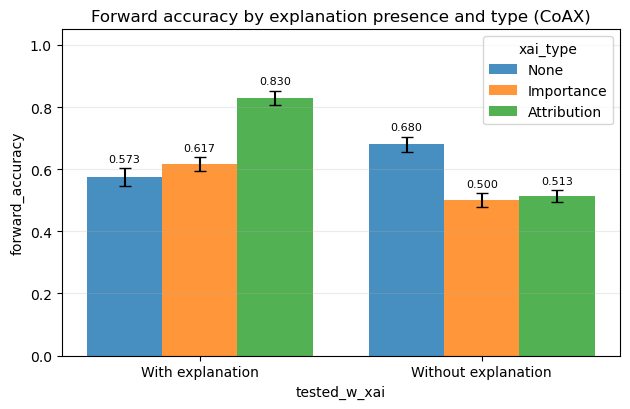

In [8]:
accuracy_plot = plot_dv_by_two_ivs(
    testing_results,
    x_iv='tested_w_xai',
    hue_iv='xai_type',
    dv='forward_accuracy',
    phase='testing',
    x_levels=[True, False],
    hue_levels=['none', 'importance', 'attribution'],
    x_labels={True: 'With explanation', False: 'Without explanation'},
    hue_labels={
        'none': 'None',
        'importance': 'Importance',
        'attribution': 'Attribution',
    },
    title='Forward accuracy by explanation presence and type (CoAX)',
)
accuracy_plot.figure;

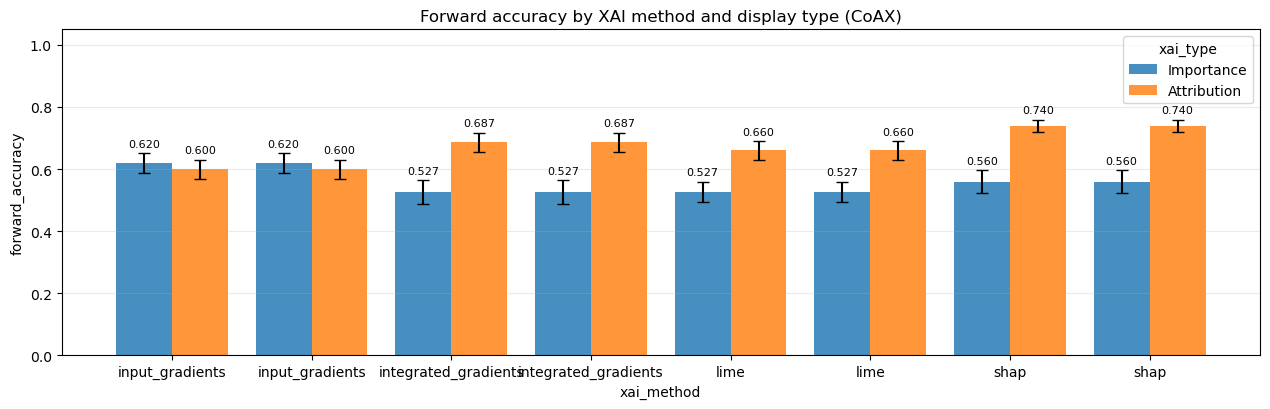

In [9]:
# The other XAI factor: does the algorithm behind the vector matter?
method_plot = plot_dv_by_two_ivs(
    testing_results.query("xai_type != 'none'"),
    x_iv='xai_method',
    hue_iv='xai_type',
    dv='forward_accuracy',
    phase='testing',
    hue_levels=['importance', 'attribution'],
    hue_labels={'importance': 'Importance', 'attribution': 'Attribution'},
    title='Forward accuracy by XAI method and display type (CoAX)',
)
method_plot.figure;

## Before a human study

Treat this output as a machine-proxy check, not evidence about people. The sample
size already matches the export; freeze stimuli and analysis rules, justify that
sample size, and obtain ethics approval where required.

The CoAX strategy parameters registered in section 4 are hand-set, not fitted to
this dataset, and `sensitivity` in particular drives accuracy strongly. Dropping
`cognitive_model=coax_models` from the `run_coax_study` call instead uses
`FITTED_COAX_PARAMS` — the per-strategy means of the parameters fitted to the
original CoAX study participants in
`src/cognitive_models/CoAX/results/pop_em_subset/`. Those are population means
across a different dataset and task, so they are a defensible starting point,
not a fit to this study.